# 01 — Análisis Exploratorio de Datos (EDA)

Dataset: actividades de running exportadas desde Strava (`runnnig-races-strava.csv`).  
Cada fila representa **una actividad** de un atleta: fecha/hora, distancia, tiempo, desnivel acumulado y frecuencia cardíaca media.

**Objetivos de este notebook:**
1. Entender la estructura y calidad del dataset
2. Limpiar valores nulos e inconsistencias de tipos
3. Analizar la distribución de las métricas principales
4. Calcular y visualizar la carga de entrenamiento semanal agregada

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Estilo visual consistente en todo el notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 4)

---
## 1. Carga y descripción del dataset

Cargamos el CSV con separador `;` y parseamos el timestamp directamente.  
Un vistazo inicial nos permite entender la granularidad y el rango temporal de los datos.

In [2]:
RAW_PATH = "../data/raw/runnnig-races-strava.csv"

df_raw = pd.read_csv(
    RAW_PATH,
    sep=";",
    parse_dates=["timestamp"],
    dayfirst=True,          # formato DD/MM/YYYY
    dtype={
        "athlete": str,
        "gender": str,
    },
)

print(f"Filas: {len(df_raw):,}  |  Columnas: {df_raw.shape[1]}")
print(f"Periodo: {df_raw['timestamp'].min().date()} → {df_raw['timestamp'].max().date()}")
df_raw.head()

Filas: 42,116  |  Columnas: 7
Periodo: 2000-01-04 → 2020-01-06


,athlete,gender,timestamp,distance (m),elapsed time (s),elevation gain (m),average heart rate (bpm)
0,18042525,M,2019-12-15 09:08:00,2965.8,812,17.4,150.3
1,18042525,M,2019-12-10 19:27:00,10020.8,3290,52.2,160.8
2,18042525,M,2019-12-03 19:46:00,12132.2,4027,249.0,148.9
3,18042525,M,2019-11-26 19:46:00,11631.5,4442,194.0,136.2
4,18042525,M,2019-11-19 19:45:00,11708.1,4022,250.7,146.0


In [3]:
print("=== dtypes ===")
print(df_raw.dtypes)
print("\n=== Estadísticas descriptivas ===")
df_raw.describe(include="all")

=== dtypes ===
athlete                                str
gender                                 str
timestamp                   datetime64[us]
distance (m)                       float64
elapsed time (s)                     int64
elevation gain (m)                 float64
average heart rate (bpm)           float64
dtype: object

=== Estadísticas descriptivas ===


,athlete,gender,timestamp,distance (m),elapsed time (s),elevation gain (m),average heart rate (bpm)
count,42116,41761,42116,42116.000000,4.211600e+04,42116.000000,23732.000000
unique,116,2,NaN,NaN,NaN,NaN,NaN
top,13435425,M,NaN,NaN,NaN,NaN,NaN
freq,1215,32289,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2018-02-15 18:57:50.886598,11028.352189,4.245974e+03,242.222516,147.652225
min,NaN,NaN,2000-01-04 12:06:00,0.000000,0.000000e+00,0.000000,0.000000
25%,NaN,NaN,2017-05-01 07:49:00,7189.600000,2.489750e+03,31.800000,138.600000
50%,NaN,NaN,2018-05-21 09:19:30,10136.750000,3.442000e+03,86.000000,148.400000
75%,NaN,NaN,2019-03-18 05:29:15,13236.300000,4.593250e+03,240.800000,158.100000
max,NaN,NaN,2020-01-06 05:24:00,218950.000000,2.971531e+06,12078.500000,237.000000


---
## 2. Limpieza básica de nulos y tipos

Antes de analizar, debemos garantizar que:
- El género tenga solo valores válidos (`M` / `F`), descartando celdas vacías.
- Las columnas numéricas no contengan valores imposibles (distancia o tiempo ≤ 0).
- Las unidades se conviertan a las más usadas en análisis de running:
  - distancia → **km**
  - tiempo → **minutos**
  - ritmo → **min/km** (métrica clave en running)

In [4]:
df = df_raw.copy()

# ── 2.1 Nulos ─────────────────────────────────────────────────────────────────
print("Nulos por columna (antes):")
print(df.isnull().sum())

# Género vacío → NaN, luego eliminamos esas filas (no podemos imputar)
df["gender"] = df["gender"].str.strip().replace("", np.nan)
df = df.dropna(subset=["gender"])

# Eliminamos filas con FC nula (actividades sin monitor cardíaco)
df = df.dropna(subset=["average heart rate (bpm)"])

print(f"\nFilas tras eliminar nulos: {len(df):,}  (descartadas: {len(df_raw) - len(df):,})")

# ── 2.2 Valores físicamente imposibles ────────────────────────────────────────
df = df[(df["distance (m)"] > 0) & (df["elapsed time (s)"] > 0)]

# ── 2.3 Conversión de unidades y columnas derivadas ───────────────────────────
df = df.rename(columns={
    "distance (m)": "distance_m",
    "elapsed time (s)": "elapsed_s",
    "elevation gain (m)": "elevation_m",
    "average heart rate (bpm)": "hr_bpm",
})

df["distance_km"]  = df["distance_m"] / 1000
df["elapsed_min"]  = df["elapsed_s"] / 60
# Ritmo en min/km — métrica estándar en running
df["pace_min_km"]  = df["elapsed_min"] / df["distance_km"]

# Filtramos ritmos imposibles: < 2 min/km (sprint puro) o > 20 min/km (caminata)
df = df[(df["pace_min_km"] >= 2) & (df["pace_min_km"] <= 20)]

# Columnas temporales útiles para agregaciones
df["date"]       = df["timestamp"].dt.date
df["year"]       = df["timestamp"].dt.year
df["week"]       = df["timestamp"].dt.to_period("W")   # período semanal
df["month"]      = df["timestamp"].dt.to_period("M")

print(f"\nFilas limpias definitivas: {len(df):,}")
df[["athlete", "gender", "timestamp", "distance_km", "elapsed_min", "pace_min_km", "hr_bpm", "elevation_m"]].head()

Nulos por columna (antes):
athlete                         0
gender                        355
timestamp                       0
distance (m)                    0
elapsed time (s)                0
elevation gain (m)              0
average heart rate (bpm)    18384
dtype: int64

Filas tras eliminar nulos: 23,535  (descartadas: 18,581)

Filas limpias definitivas: 23,318


,athlete,gender,timestamp,distance_km,elapsed_min,pace_min_km,hr_bpm,elevation_m
0,18042525,M,2019-12-15 09:08:00,2.9658,13.533333,4.563131,150.3,17.4
1,18042525,M,2019-12-10 19:27:00,10.0208,54.833333,5.471952,160.8,52.2
2,18042525,M,2019-12-03 19:46:00,12.1322,67.116667,5.532110,148.9,249.0
3,18042525,M,2019-11-26 19:46:00,11.6315,74.033333,6.364900,136.2,194.0
4,18042525,M,2019-11-19 19:45:00,11.7081,67.033333,5.725381,146.0,250.7


---
## 3. Distribución de las métricas principales

Analizamos la distribución de cada métrica clave para entender el perfil de los atletas:
- **Distancia** y **ritmo** definen el tipo de entrenamiento (rodaje corto, medio, largo).
- **Frecuencia cardíaca** revela la intensidad.
- **Desnivel** diferencia terreno llano de montaña.

Usamos histogramas con KDE para ver la forma de la distribución y detectar outliers.

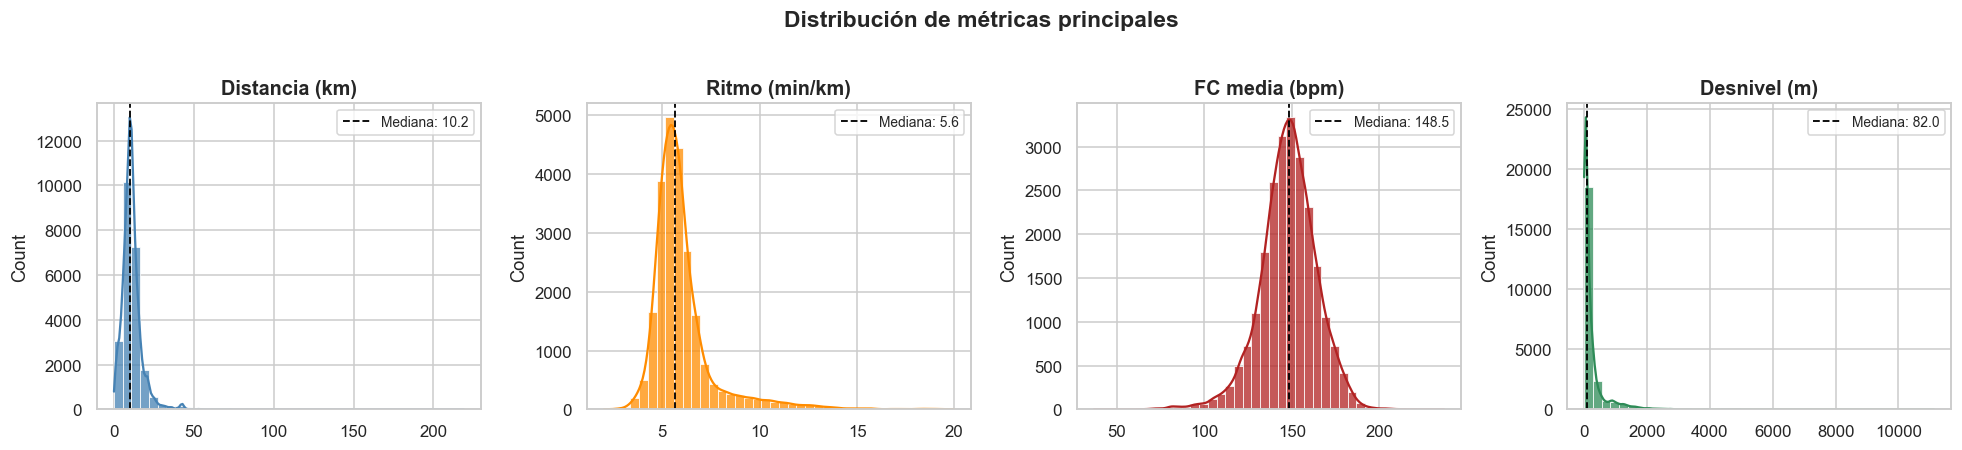

In [5]:
# ── Gráfico 1: Distribución de las 4 métricas principales ────────────────────
metrics = {
    "distance_km":  ("Distancia (km)", "steelblue"),
    "pace_min_km":  ("Ritmo (min/km)", "darkorange"),
    "hr_bpm":       ("FC media (bpm)", "firebrick"),
    "elevation_m":  ("Desnivel (m)", "seagreen"),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (col, (label, color)) in zip(axes, metrics.items()):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color=color, alpha=0.75)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    median_val = df[col].median()
    ax.axvline(median_val, color="black", linestyle="--", linewidth=1.2, label=f"Mediana: {median_val:.1f}")
    ax.legend(fontsize=9)

fig.suptitle("Distribución de métricas principales", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

/var/folders/sz/tcwshbld2ks22flzhl8_rqfh0000gn/T/ipykernel_31636/1246198258.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="gender", y=col, palette=palette, ax=ax,
/var/folders/sz/tcwshbld2ks22flzhl8_rqfh0000gn/T/ipykernel_31636/1246198258.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="gender", y=col, palette=palette, ax=ax,
/var/folders/sz/tcwshbld2ks22flzhl8_rqfh0000gn/T/ipykernel_31636/1246198258.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="gender", y=col, palette=palette, ax=ax,


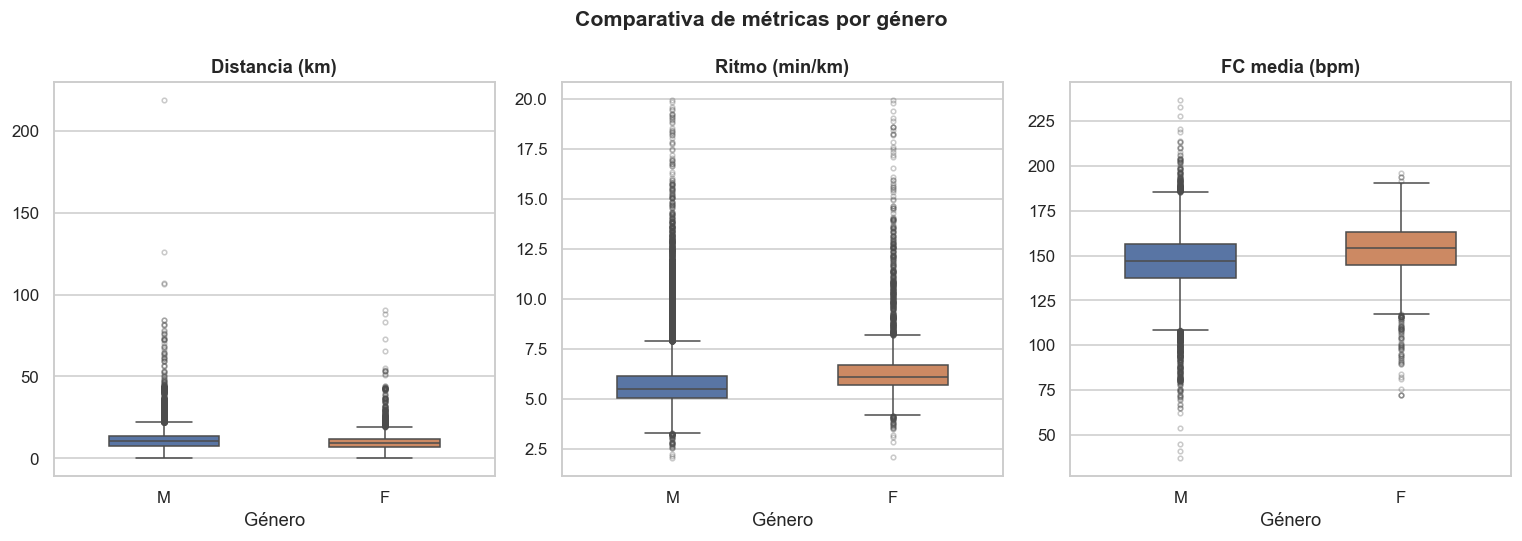

In [6]:
# ── Gráfico 2: Boxplot por género ─────────────────────────────────────────────
# Comparar las métricas por género nos permite ver si hay diferencias sistemáticas
# en cómo entrenan atletas M y F (distancia, ritmo, intensidad).

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

comparisons = [
    ("distance_km", "Distancia (km)"),
    ("pace_min_km", "Ritmo (min/km)"),
    ("hr_bpm",      "FC media (bpm)"),
]

palette = {"M": "#4C72B0", "F": "#DD8452"}

for ax, (col, label) in zip(axes, comparisons):
    sns.boxplot(data=df, x="gender", y=col, palette=palette, ax=ax,
                order=["M", "F"], width=0.5, flierprops=dict(marker=".", alpha=0.3))
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Género")
    ax.set_ylabel("")

fig.suptitle("Comparativa de métricas por género", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

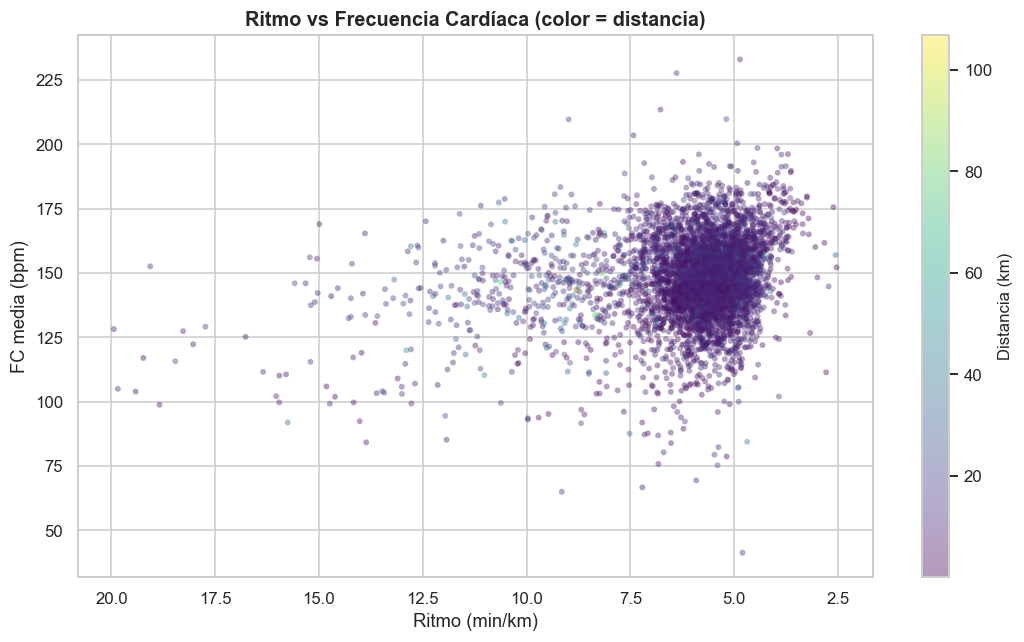

In [7]:
# ── Gráfico 3: Scatter ritmo vs FC coloreado por distancia ────────────────────
# Queremos entender si los atletas que corren más rápido también tienen mayor FC,
# y si la distancia de la actividad modula esa relación (esfuerzo sostenido).
# Muestra aleatoria para no saturar el gráfico con 40k puntos.

sample = df.sample(n=5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    sample["pace_min_km"],
    sample["hr_bpm"],
    c=sample["distance_km"],
    cmap="viridis",
    alpha=0.4,
    s=15,
    edgecolors="none",
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Distancia (km)", fontsize=11)
ax.set_xlabel("Ritmo (min/km)", fontsize=12)
ax.set_ylabel("FC media (bpm)", fontsize=12)
ax.set_title("Ritmo vs Frecuencia Cardíaca (color = distancia)", fontsize=13, fontweight="bold")

# Invertimos el eje X: ritmo menor = más rápido → valores bajos a la derecha
ax.invert_xaxis()
plt.tight_layout()
plt.show()

---
## 4. Carga semanal agregada

En running, la **carga de entrenamiento** se mide habitualmente en kilómetros semanales.
Agregaremos por semana calendario para detectar:
- Tendencias de volumen a lo largo del tiempo
- Semanas de descarga (típicas en planes de entrenamiento estructurado)
- Estacionalidad (¿se corre menos en invierno?)

También calcularemos el **número de sesiones por semana** como indicador de frecuencia.

In [8]:
# Agregación semanal por atleta: km totales, sesiones, FC media, ritmo medio
weekly = (
    df.groupby(["athlete", "week"], as_index=False)
    .agg(
        km_total    =("distance_km", "sum"),
        sessions    =("distance_km", "count"),
        hr_mean     =("hr_bpm",      "mean"),
        pace_mean   =("pace_min_km", "mean"),
        elev_total  =("elevation_m", "sum"),
    )
)

# Para la visualización temporal, agregamos TODOS los atletas juntos por semana
weekly_all = (
    df.groupby("week", as_index=False)
    .agg(
        km_total    =("distance_km", "sum"),
        sessions    =("distance_km", "count"),
        athletes    =("athlete",     "nunique"),
    )
)
# Ordenamos cronológicamente
weekly_all = weekly_all.sort_values("week")
weekly_all["week_str"] = weekly_all["week"].astype(str)

print(f"Semanas únicas: {weekly_all['week'].nunique()}")
print(f"Semanas con más km: {weekly_all.nlargest(3, 'km_total')[['week_str','km_total','sessions']].to_string(index=False)}")
weekly_all.head()

Semanas únicas: 355
Semanas con más km:              week_str  km_total  sessions
2019-05-06/2019-05-12 2286.3355       182
2019-03-04/2019-03-10 2284.2862       194
2019-02-25/2019-03-03 2181.8025       182


,week,km_total,sessions,athletes,week_str
0,2000-01-03/2000-01-09,1.7070,1,1,2000-01-03/2000-01-09
1,2012-09-10/2012-09-16,6.2028,1,1,2012-09-10/2012-09-16
2,2012-09-17/2012-09-23,40.1680,2,1,2012-09-17/2012-09-23
3,2012-09-24/2012-09-30,52.1676,4,1,2012-09-24/2012-09-30
4,2012-10-01/2012-10-07,17.3212,2,1,2012-10-01/2012-10-07


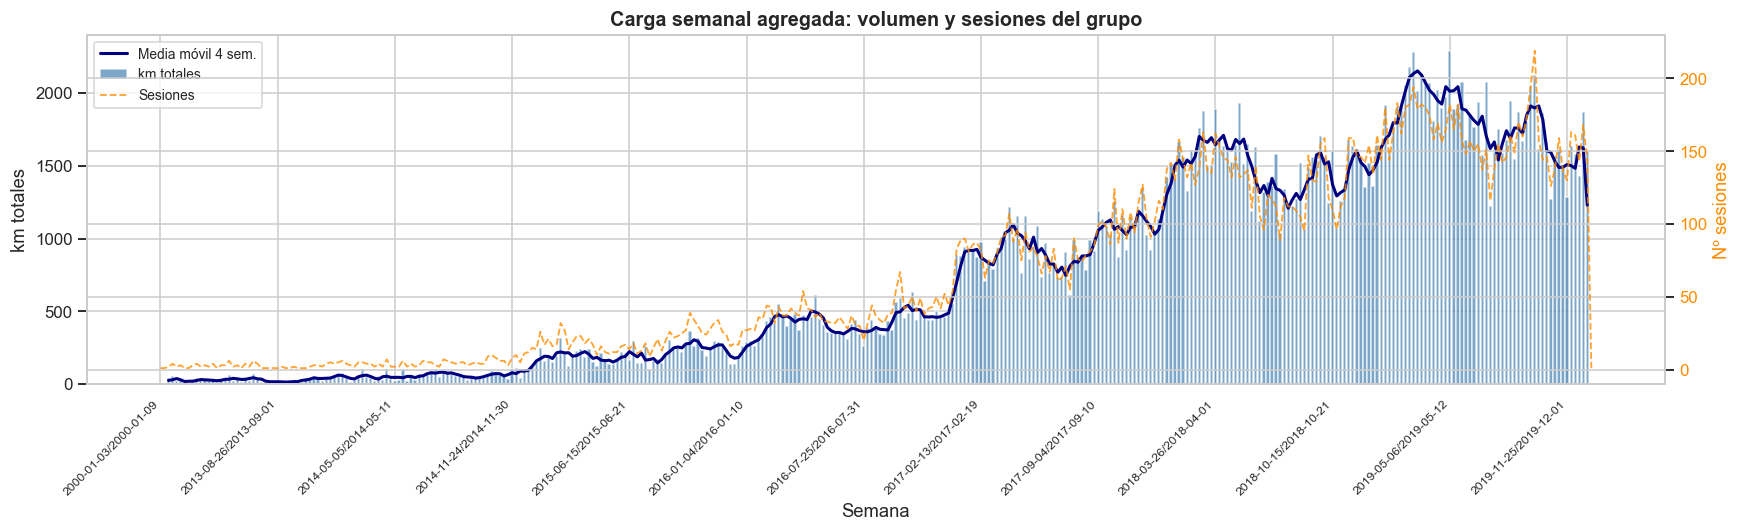

In [9]:
# ── Gráfico 4: Volumen semanal total del grupo ────────────────────────────────
# Este gráfico muestra la evolución temporal de la carga colectiva:
# cuántos km acumulan TODOS los atletas cada semana. Es útil para detectar
# períodos de alta actividad (acumulación previa a competiciones) y descansos.

# Usamos índice numérico para el eje X y ponemos etiquetas cada N semanas
n_weeks = len(weekly_all)
tick_step = max(1, n_weeks // 12)   # ~12 etiquetas en el eje X

fig, ax1 = plt.subplots(figsize=(16, 5))

# Barras: km totales por semana
ax1.bar(
    range(n_weeks),
    weekly_all["km_total"],
    color="steelblue",
    alpha=0.7,
    label="km totales",
)
# Media móvil de 4 semanas para suavizar la tendencia
rolling_km = weekly_all["km_total"].rolling(4, center=True).mean()
ax1.plot(range(n_weeks), rolling_km, color="navy", linewidth=2, label="Media móvil 4 sem.")
ax1.set_ylabel("km totales", fontsize=12)
ax1.set_xlabel("Semana", fontsize=12)

# Eje secundario: número de sesiones
ax2 = ax1.twinx()
ax2.plot(range(n_weeks), weekly_all["sessions"], color="darkorange", linewidth=1.2,
         linestyle="--", alpha=0.8, label="Sesiones")
ax2.set_ylabel("Nº sesiones", fontsize=12, color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

# Etiquetas del eje X (fechas de inicio de semana)
ax1.set_xticks(range(0, n_weeks, tick_step))
ax1.set_xticklabels(weekly_all["week_str"].iloc[::tick_step], rotation=45, ha="right", fontsize=8)

# Leyenda combinada de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title("Carga semanal agregada: volumen y sesiones del grupo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

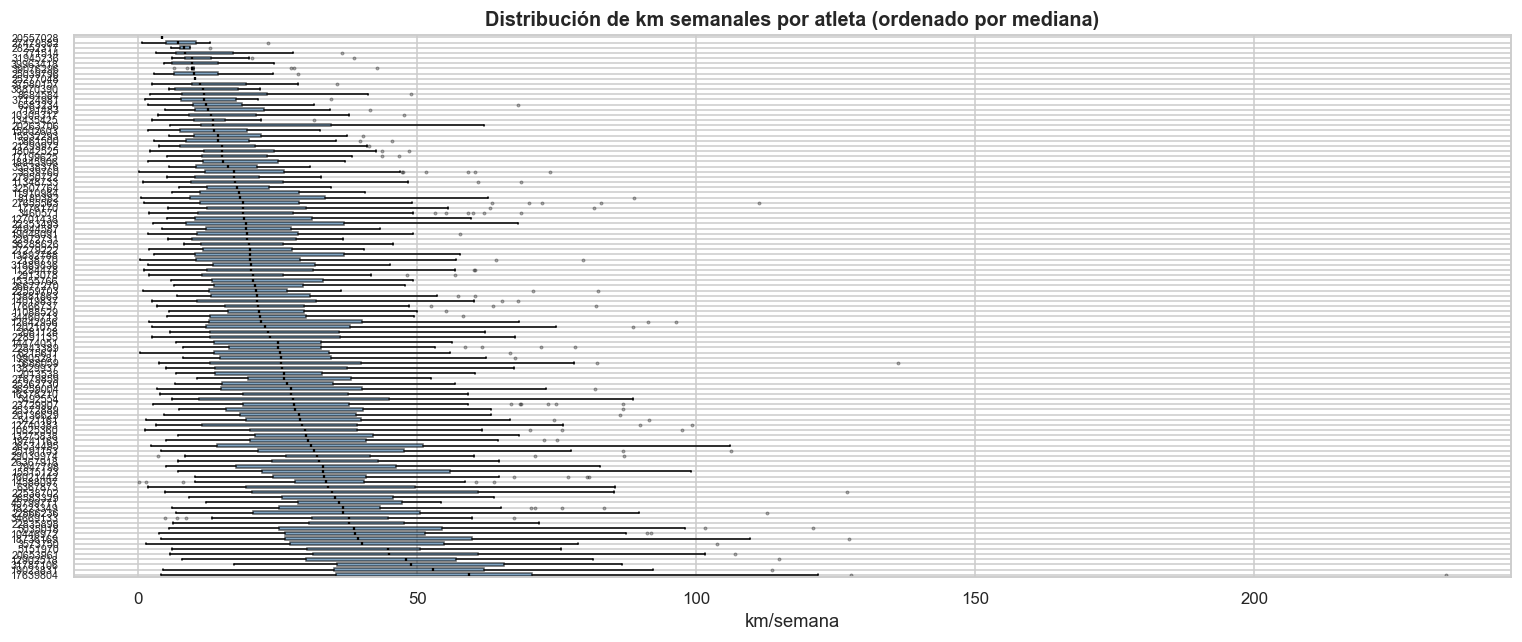

In [10]:
# ── Gráfico 5: Distribución de km semanales por atleta (heatmap calendario) ───
# La distribución de km semanales POR ATLETA revela la heterogeneidad del grupo:
# algunos atletas son muy consistentes, otros tienen alta variabilidad.
# Usamos un boxplot con un punto por atleta para mostrar mediana e IQR.

# Pivotamos: atleta × semana → km (NaN si no entrenó esa semana)
pivot = weekly.pivot_table(index="athlete", columns="week", values="km_total", fill_value=0)

# Estadísticas por atleta
athlete_stats = (
    weekly.groupby("athlete")["km_total"]
    .agg(mediana="median", p75=lambda x: x.quantile(0.75), total="sum", semanas="count")
    .sort_values("mediana", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

# Boxplot horizontal: cada fila es un atleta, ordenado por mediana de km/semana
bplot = ax.boxplot(
    [weekly[weekly["athlete"] == ath]["km_total"].values
     for ath in athlete_stats["athlete"]],
    vert=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=1.5),
    flierprops=dict(marker=".", markersize=3, alpha=0.4),
    boxprops=dict(facecolor="steelblue", alpha=0.6),
)

ax.set_yticks(range(1, len(athlete_stats) + 1))
ax.set_yticklabels(athlete_stats["athlete"], fontsize=7)
ax.set_xlabel("km/semana", fontsize=12)
ax.set_title("Distribución de km semanales por atleta (ordenado por mediana)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 5. Resumen y próximos pasos

### Lo que encontramos

| Métrica | Observación |
|---|---|
| **Dataset limpio** | ~42k actividades, periodo multi-año, 116 atletas |
| **Distancia típica** | Mediana ~10 km — predominan rodajes medios |
| **Ritmo típico** | Mediana ~5-6 min/km — rango amateur-avanzado |
| **FC media** | Mediana ~150 bpm — intensidad moderada-alta |
| **Carga semanal** | Alta variabilidad entre atletas; patrón de acumulación/descarga visible |

### Próximos notebooks sugeridos
- `02_athlete_profiles.ipynb` — clustering de atletas por perfil de entrenamiento
- `03_performance_prediction.ipynb` — modelo de predicción de ritmo en función de distancia, FC y desnivel
- `04_training_load.ipynb` — métricas avanzadas: TRIMP, monotonía, strain